---
numbering:
  enumerator: "13.%s"
  equation:
    template: "%s"  
---

%# (PART) From predictions to portfolios {-} 

(chap_valtune)=
# Validating and tuning

As is shown in Chapters {ref}`chap_lasso` to {ref}`chap_ensemble`, ML models require user-specified choices before they can be trained. These choices encompass parameter values (learning rate, penalization intensity, etc.) or architectural choices (e.g., the structure of a network). Alternative designs in ML engines can lead to different predictions, hence selecting a good one can be critical. We refer to the work of @probst2018tunability for a study on the impact of hyperparameter tuning on model performance. For some models (neural networks and boosted trees), the number of degrees of freedom is so large that finding the right parameters can become complicated and challenging. This chapter addresses these issues but the reader must be aware that there is no shortcut to building good models. Crafting an effective model is time-consuming and often the result of many iterations.

## Learning metrics

The parameter values that are set before training are called **hyperparameters**. In order to be able to choose good hyperparameters, it is imperative to define metrics that evaluate the performance of ML models. As is often the case in ML, there is a dichotomy between models that seek to predict numbers (regressions) and those that try to forecast categories (classifications). Before we outline common evaluation benchmarks, we mention the econometric approach of @li2020conditional. The authors propose to assess the performance of a forecasting method compared to a given benchmark, **conditional** on some external variable. This helps monitor under which (economic) conditions the model beats the benchmark. The full implementation of the test is intricate, and we recommend the interested reader have a look at the derivations in the paper.

### Regression analysis

Errors in regression analyses are usually evaluated in a straightforward way. The $L^1$ and $L^2$ norms are mainstream; they are both easy to interpret and to compute. The second one, the root **mean squared error** (RMSE) is differentiable everywhere but harder to grasp and gives more weight to outliers. The first one, the mean absolute error gives the average distance to the realized value but is not differentiable at zero. Formally, we define them as

$$
\text{MAE}(\textbf{y},\tilde{\textbf{y}})=\frac{1}{I}\sum_{i=1}^I|y_i-\tilde{y}_i|,
$$ (eq-MAE)

$$
\text{MSE}(\textbf{y},\tilde{\textbf{y}})=\frac{1}{I}\sum_{i=1}^I(y_i-\tilde{y}_i)^2,
$$ (eq-MSE)

and the RMSE is simply the square root of the MSE. It is always possible to generalize these formulae by adding weights $w_i$ to produce heterogeneity in the importance of instances. Let us briefly comment on the MSE. It is by far the most common loss function in machine learning, but it is not necessarily the exact best choice for return prediction in a portfolio allocation task. If we decompose the loss into its 3 terms, we get the sum of squared realized returns, the sum of squared predicted returns and the product between the two (roughly speaking, a covariance term if we assume zero means). The first term does not matter. The second controls the dispersion around zero of the predictions. The third term is the most interesting from the allocator's standpoint. The negativity of the cross-product $-2y_i\tilde{y}_i$ is always to the investor's benefit: either both terms are positive and the model has recognized a profitable asset, or they are negative and it has identified a bad opportunity. It is when $y_i$ and $\tilde{y}_i$ don't have the same sign that problems arise. Thus, compared to the $\tilde{y}_i^2$, the cross-term is more important. Nonetheless, algorithms do not optimize with respect to this indicator.[^12-fn1] 

These metrics (MSE and RMSE) are widely used outside ML to assess forecasting errors. Below, we present other indicators that are also sometimes used to quantify the quality of a model. In line with the linear regressions, the $R^2$ can be computed in any predictive exercise. 

$$
R^2(\textbf{y},\tilde{\textbf{y}})=1- \frac{\sum_{i=1}^I(y_i-\tilde{y}_i)^2}{\sum_{i=1}^I(y_i-\bar{y})^2},
$$ (eq-R2)

where $\bar{y}$ is the sample average of the label. One important difference with the classical $R^2$ is that the above quantity can be computed on the **testing sample** and not on the **training sample**. In this case, the $R^2$ can be negative when the mean squared error in the numerator is larger than the (biased) variance of the testing sample. Sometimes, the average value $\bar{y}$ is omitted in the denominator (as in @gu2018empirical for instance). The benefit of removing the average value is that it compares the predictions of the model to a zero prediction. This is particularly relevant with returns because the simplest prediction of all is the constant zero value and the $R^2$ can then measure if the model beats this naive benchmark. A zero prediction is always preferable to a sample average because the latter can be very much period dependent. Also, removing $\bar{y}$ in the denominator makes the metric more conservative as it mechanically reduces the $R^2$.

Beyond the simple indicators detailed above, several exotic extensions exist and they all consist in altering the error before taking the averages. Two notable examples are the Mean Absolute Percentage Error (MAPE) and the Mean Square Percentage Error (MSPE). Instead of looking at the raw error, they compute the error relative to the original value (to be predicted). Hence, the error is expressed in a percentage score and the averages are simply equal to:

$$
\text{MAPE}(\textbf{y},\tilde{\textbf{y}})=\frac{1}{I}\sum_{i=1}^I\left|\frac{y_i-\tilde{y}_i}{y_i}\right|,
$$ (eq-MAPE)

$$
\text{MSPE}(\textbf{y},\tilde{\textbf{y}})=\frac{1}{I}\sum_{i=1}^I\left(\frac{y_i-\tilde{y}_i}{y_i}\right)^2,
$$ (eq-MSPE)

where the latter can be scaled by a square root if need be. When the label is positive with possibly large values, it is possible to scale the magnitude of errors, which can be very large. One way to do this is to resort to the Root Mean Squared Logarithmic Error (RMSLE), defined below:

$$
\text{RMSLE}(\textbf{y},\tilde{\textbf{y}})=\sqrt{\frac{1}{I}\sum_{i=1}^I\log\left(\frac{1+y_i}{1+\tilde{y}_i}\right)},
$$ (eq-RMSLE)

where it is obvious that when $y_i=\tilde{y}_i$, the error metric is equal to zero. 

Before we move on to categorical losses, we briefly comment on one shortcoming of the MSE, which is by far the most widespread metric and objective in regression tasks. A simple decomposition yields:

$$\text{MSE}(\textbf{y},\tilde{\textbf{y}})=\frac{1}{I}\sum_{i=1}^I(y_i^2+\tilde{y}_i^2-2y_i\tilde{y}_i).$$

In the sum, the first term is given, there is nothing to be done about it, hence models focus on the minimization of the other two. The second term is the dispersion of model values. The third term is a cross-product. While variations in $\tilde{y}_i$ do matter, the third term is by far the most important, especially in the cross-section. It is more valuable to reduce the MSE by increasing $y_i\tilde{y}_i$. This product is indeed positive when the two terms have the same sign, which is exactly what an investor is looking for: **correct directions** for the bets. For some algorithms (like neural networks), it is possible to manually specify custom losses. Maximizing the sum of $y_i\tilde{y}_i$ may be a good alternative to vanilla quadratic optimization (see {ref}`custloss` for an example of implementation).

[^12-fn1]: There are some exceptions, like attempts to optimize more exotic criteria, such as the Spearman rho, which is based on rankings and is close in spirit to maximizing the correlation between the output and the prediction. Because this rho cannot be differentiated, this causes numerical issues. These problems can be partially alleviated when resorting to complex architectures, as in @engilberge2019sodeep.


### Classification analysis

The performance metrics for categorical outcomes are substantially different compared to those of numerical outputs. A large proportion of these metrics are dedicated to binary classes, though some of them can easily be generalized to multiclass models.

We present the concepts pertaining to these metrics in an increasing order of complexity and start with the two dichotomies true versus false and positive versus negative. In binary classification, it is convenient to think in terms of true versus false. In an investment setting, true can be related to a positive return, or a return being above that of a benchmark - false being the opposite.

There are then 4 types of possible results for a prediction. Two when the prediction is right (predict true with true realization or predict false with false outcome) and two when the prediction is wrong (predict true with false realization and the opposite). We define the corresponding aggregate metrics below:

- frequency of true positive: $TP=I^{-1}\sum_{i=1}^I1_{\{y_i=\tilde{y}_i=1 \}},$  
- frequency of true negative: $TN=I^{-1}\sum_{i=1}^I1_{\{y_i=\tilde{y}_i=0 \}},$  
- frequency of false positive: $FP=I^{-1}\sum_{i=1}^I1_{\{\tilde{y}_i=1,y_i=0 \}},$  
- frequency of false negative: $FN=I^{-1}\sum_{i=1}^I1_{\{\tilde{y}_i=0,y_i=1 \}},$  

where true is conventionally encoded into 1 and false into 0. The sum of the four figures is equal to one. These four numbers have very different impacts on out-of-sample results, as is shown in [](#fig-valconfusion). In this table (also called a **confusion matrix**), it is assumed that some proxy for future profitability is forecast by the model. Each row stands for the model's prediction and each column for the realization of the profitability. The most important cases are those in the top row, when the model predicts a positive result because it is likely that assets with positive predicted profitability (possibly relative to some benchmark) will end up in the portfolio. Of course, this is not a problem if the asset does well (left cell), but it becomes penalizing if the model is wrong because the portfolio will suffer. 

```{figure} images/confusion.png
:name: fig-valconfusion
:align: center
Confusion matrix: summary of binary outcomes.
```

Among the two types of errors, **type I** is the most daunting for investors because it has a direct effect on the portfolio. The **type II** error is simply a missed opportunity and is somewhat less impactful. Finally, true negatives are those assets which are correctly excluded from the portfolio.

From the four baseline rates, it is possible to derive other interesting metrics:

- **Accuracy** = $TP+TN$ is the percentage of correct forecasts;    
- **Recall** = $\frac{TP}{TP+FN}$ measures the ability to detect a winning strategy/asset (left column analysis). Also known as sensitivity or true positive rate (TPR);    
- **Precision** = $\frac{TP}{TP+FP}$ computes the probability of good investments (top row analysis);
- **Specificity** = $\frac{TN}{FP+TN}$ measures the proportion of actual negatives that are correctly identified as such (right column analysis);
- **Fallout** = $\frac{FP}{FP+TN}=1-$Specificity is the probability of false alarm (or false positive rate), i.e., the frequence at which the algorithm detects falsely performing assets (right column analysis);  
- **F-score**, $\mathbf{F}_1=2\frac{\text{recall}\times \text{precision}}{\text{recall}+ \text{precision}}$ is the harmonic average of recall and precision.

All of these items lie in the unit interval and a model is deemed to perform better when they increase (except for fallout for which it is the opposite). Many other indicators also exist, like the false discovery rate or false omission rate, but they are not as mainstream and less cited. Moreover, they are often simple functions of the ones mentioned above.

A metric that is popular but more complex is the Area Under the (ROC) Curve, often referred to as AUC. The complicated part is the ROC curve where ROC stands for Receiver Operating Characteristic; the name comes from signal theory. We explain how it is built below.

As seen in Chapters {ref}`chap_trees` and {ref}`chap_NN`, classifiers generate output that are probabilities that one instance belongs to one class. These probabilities are then translated into a class by choosing the class that has the highest value. In binary classification, the class with a score above 0.5 basically wins. 

In practice, this 0.5 threshold may not be optimal and the model could very well correctly predict false instances when the probability is below 0.4 and true ones otherwise. Hence, it is a natural idea to test what happens if the decision threshold changes. The ROC curve does just that and plots the recall as a function of the fallout when the threshold increases from zero to one. 

When the threshold is equal to 0, true positives are equal to zero because the model never forecasts positive values. Thus, both recall and fallout are equal to zero. When the threshold is equal to one, false negatives shrink to zero and true negatives too, hence recall and fallout are equal to one. The behavior of their relationship in between these two extremes is called the **ROC curve**. We provide stylized examples below in [](#fig-ROCcurve). A random classifier would fare equally good for recall and fallout and thus the ROC curve would be a linear line from the point (0,0) to (1,1). To prove this, imagine a sample with a $p\in (0,1)$ proportion of true instances and a classifier that predicts true randomly with a probability $p'\in (0,1)$. Then because the sample and predictions are independent, $TP=p'p$, $FP = p'(1-p)$, $TN=(1-p')(1-p)$ and $FN=(1-p')p$. Given the above definition, this yields that both recall and fallout are equal to $p'$.  

```{figure} images/ROCcurve.png
:name: fig-ROCcurve
:align: center
Stylized ROC curves.
```

An algorithm with a ROC curve above the 45° angle is performing better than an average classifier. Indeed, the curve can be seen as a tradeoff between benefits (probability of detecting good strategies on the $y$ axis) minus costs (odds of selecting the wrong assets on the $x$ axis). Hence being above the 45° is paramount. The best possible classifier has a ROC curve that goes from point (0,0) to point (0,1) to point (1,1). At point (0,1), fallout is null, hence there are no false positives, and recall is equal to one so that there are also no false negatives: the model is always right. The opposite is true: at point (1,0), the model is always wrong.

Below, we use sklearn to compute and display a ROC curve for a given set of predictions on the testing sample.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [1]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.linear_model import Ridge
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Building the data & import functions
from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()
features_short = ["Div_yld", "EPS", "size_avg_252d", "mom_252", "OCF_Growth_1Y", "PB", "vol_252"]
separation_date = "2017-01-15"

data_ml_clean = data_ml.dropna(subset=(features_short + ['R1M']))
training_sample = data_ml_clean[data_ml_clean['date'] <= separation_date]
testing_sample = data_ml_clean[data_ml_clean['date'] > separation_date]

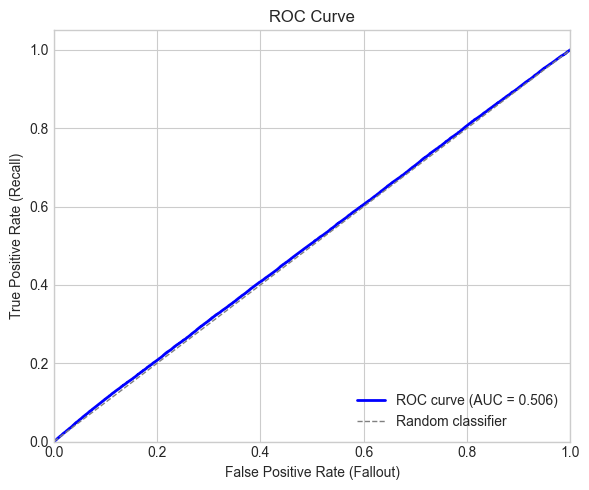

In [2]:
#| label: fig-roc
#| fig-cap: "Example of ROC curve."

# Prepare data for classification
X_train = training_sample[features_short]
y_train_C = training_sample['R1M_C']
X_test = testing_sample[features_short]
y_test_C = testing_sample['R1M_C']

# Train Random Forest Classifier (similar to fit_RF_C from chapter 6)
fit_RF_C = RandomForestClassifier(
    n_estimators=40,
    max_samples=20000,
    bootstrap=True,
    min_samples_leaf=250,
    max_features=5,
    random_state=42
)
fit_RF_C.fit(X_train, y_train_C)

# Get predicted probabilities for the positive class
y_proba = fit_RF_C.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_C, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fallout)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
print(f"AUC: {roc_auc:.4f}")


AUC: 0.5063


In [](#fig-roc), the curve is very close to the 45° angle and the model seems as good (or, rather, as bad) as a random classifier.

Finally, having one entire curve is not practical for comparison purposes, hence the information of the whole curve is synthesized into the area below the curve, i.e., the integral of the corresponding function. The 45° angle (quadrant bisector) has an area of 0.5 (it is half the unit square which has a unit area). Thus, any good model is expected to have an area under the curve (AUC) above 0.5. A perfect model has an AUC of one.

We end this subsection with a word on multiclass data. When the output (i.e., the label) has more than two categories, things become more complex. It is still possible to compute a confusion matrix, but the dimension is larger and harder to interpret. The simple indicators like $TP$, $TN$, etc., must be generalized in a non-standard way. The simplest metric in this case is the cross-entropy defined in Equation {eq}`eq-crossentropy`. We refer to {ref}`sec_treeclass` for more details on losses related to categorical labels.

## Validation

Validation is the stage at which a model is tested and tuned before it starts to be deployed on real or live data (e.g., for trading purposes). Needless to say, it is critical.

### The variance-bias tradeoff: theory

The **variance-bias tradeoff** is one of the core concepts in supervised learning. To explain it, let us assume that the data is generated by the simple model

$$y_i=f(\textbf{x}_i)+\epsilon_i, \quad   \mathbb{E}[\boldsymbol{\epsilon}]=0, \quad \mathbb{V}[\boldsymbol{\epsilon}]=\sigma^2,$$

but the model that is estimated yields

$$y_i=\hat{f}(\textbf{x}_i)+\hat{\epsilon}_i. $$

Given an unknown sample $\textbf{x}$, the decomposition of the average squared error is 

$$
\begin{aligned}
\mathbb{E}[\hat{\epsilon}^2]&=\mathbb{E}[(y-\hat{f}(\textbf{x}))^2]=\mathbb{E}[(f(\textbf{x})+\epsilon-\hat{f}(\textbf{x}))^2]   \\
&= \underbrace{\mathbb{E}[(f(\textbf{x})-\hat{f}(\textbf{x}))^2]}_{\text{total quadratic error}}+\underbrace{\mathbb{E}[\epsilon^2]}_{\text{irreducible error}} \\
&= \mathbb{E}[\hat{f}(\textbf{x})^2]+\mathbb{E}[f(\textbf{x})^2]-2\mathbb{E}[f(\textbf{x})\hat{f}(\textbf{x})]+\sigma^2\\
&=\mathbb{E}[\hat{f}(\textbf{x})^2]+f(\textbf{x})^2-2f(\textbf{x})\mathbb{E}[\hat{f}(\textbf{x})]+\sigma^2\\
&=\left[ \mathbb{E}[\hat{f}(\textbf{x})^2]-\mathbb{E}[\hat{f}(\textbf{x})]^2\right]+\left[\mathbb{E}[\hat{f}(\textbf{x})]^2+f(\textbf{x})^2-2f(\textbf{x})\mathbb{E}[\hat{f}(\textbf{x})]\right]+\sigma^2\\
&=\underbrace{\mathbb{V}[\hat{f}(\textbf{x})]}_{\text{variance of model}}+ \quad \underbrace{\mathbb{E}[(f(\textbf{x})-\hat{f}(\textbf{x}))]^2}_{\text{squared bias}}\quad +\quad\sigma^2
\end{aligned}
$$ (eq-biasvariance)

In the above derivation, $f(x)$ is not random, but $\hat{f}(x)$ is. Also, in the second line, we assumed $\mathbb{E}[\epsilon(f(x)-\hat{f}(x))]=0$, which may not always hold (though it is a very common assumption). The average squared error thus has three components:  
   
- the variance of the model (over its predictions);   
- the squared bias of the model;    
- and one **irreducible error** (independent from the choice of a particular model).      

The last one is immune to changes in models, so the challenge is to minimize the sum of the first two. This is known as the variance-bias tradeoff because reducing one often leads to increasing the other. The goal is thus to assess when a small increase in either one can lead to a larger decrease in the other.

There are several ways to represent this tradeoff and we display two of them. The first one relates to archery (see [](#fig-archery)) below. The best case (top left) is when all shots are concentrated in the middle: on average, the archer aims correctly and all the arrows are very close to one another. The worst case (bottom right) is the exact opposite: the average arrow is above the center of the target (the bias is nonzero) and the dispersion of arrows is large.

```{figure} images/var_bias_trade.png
:name: fig-archery
:align: center
First representation of the variance-bias tradeoff.
```

The most often encountered cases in ML are the other two configurations: either the arrows (predictions) are concentrated in a small perimeter, but the perimeter is not the center of the target; or the arrows are on average well distributed around the center, but they are, on average, far from it.

The second way the variance bias tradeoff is often depicted is via the notion of **model complexity**. The most simple model of all is a constant one: the prediction is always the same, for instance equal to the average value of the label in the training set. Of course, this prediction will often be far from the realized values of the testing set (its bias will be large), but at least its variance is zero. On the other side of the spectrum, a decision tree with as many leaves as there are instances has a very complex structure. It will probably have a smaller bias, but undoubtedly it is not obvious that this will compensate the increase in variance incurred by the intricacy of the model. 

This facet of the tradeoff is depicted in [](#fig-varbiastrade) below. To the left of the graph, a simple model has a small variance but a large bias, while to the right it is the opposite for a complex model. Good models often lie somewhere in the middle, but the best mix is hard to find.

```{figure} images/var_bias_trade2.png
:name: fig-varbiastrade
:align: center
Second representation of the variance-bias tradeoff.
```

The most tractable theoretical form of the variance-bias tradeoff is the ridge regression.[^12-fn2] The coefficient estimates in this type of regression are given by $\hat{\mathbf{b}}_\lambda=(\mathbf{X}'\mathbf{X}+\lambda \mathbf{I}_N)^{-1}\mathbf{X}'\mathbf{Y}$ (see {ref}`penreg`), where $\lambda$ is the penalization intensity. Assuming a *true* linear form for the data generating process ($\textbf{y}=\textbf{Xb}+\boldsymbol{\epsilon}$ where $\textbf{b}$ is unknown and $\sigma^2$ is the variance of errors - which have identity correlation matrix), this yields

$$
\begin{aligned}  
\mathbb{E}[\hat{\textbf{b}}_\lambda]&=\textbf{b}-\lambda(\textbf{X}'\textbf{X}+\lambda \textbf{I}_N)^{-1} \textbf{b}, \\
\mathbb{V}[\hat{\textbf{b}}_\lambda]&=\sigma^2(\textbf{X}'\textbf{X}+\lambda \textbf{I}_N)^{-1}\textbf{X}'\textbf{X}   (\textbf{X}'\textbf{X}+\lambda \textbf{I}_N)^{-1}.
\end{aligned}
$$ (eq-vartrade)

Basically, this means that the bias of the estimator is equal to $-\lambda(\textbf{X}'\textbf{X}+\lambda \textbf{I}_N)^{-1} \textbf{b}$, which is zero in the absence of penalization (classical regression) and converges to some finite number when $\lambda \rightarrow \infty$, i.e., when the model becomes constant. Note that if the estimator has a zero bias, then predictions will too: $\mathbb{E}[\textbf{X}(\textbf{b}-\hat{\textbf{b}})]=\textbf{0}$. 

The variance (of estimates) in the case of an unconstrained regression is equal to $\mathbb{V}[\hat{\textbf{b}}]=\sigma (\textbf{X}'\textbf{X})^{-1}$. In Equation {eq}`eq-vartrade`, the $\lambda$ reduces the magnitude of figures in the inverse matrix. The overall effect is that as $\lambda$ increases, the variance decreases and in the limit $\lambda \rightarrow \infty$, the variance is zero when the model is constant. The variance of predictions is

$$
\begin{aligned}
\mathbb{V}[\textbf{X}\hat{\textbf{b}}]&=\mathbb{E}[(\textbf{X}\hat{\textbf{b}}-\mathbb{E}[\textbf{X}\hat{\textbf{b}}])(\textbf{X}\hat{\textbf{b}}-\mathbb{E}[\textbf{X}\hat{\textbf{b}}])'] \\
&= \textbf{X}\mathbb{E}[(\hat{\textbf{b}}-\mathbb{E}[\hat{\textbf{b}}])(\hat{\textbf{b}}-\mathbb{E}[\hat{\textbf{b}}])']\textbf{X}' \\
&= \textbf{X}\mathbb{V}[\hat{\textbf{b}}]\textbf{X}
\end{aligned}
$$

All in all, ridge regressions are very handy because with a single parameter, they are able to provide a cursor that directly tunes the variance-bias tradeoff.

It's easy to illustrate how simple it is to display the tradeoff with the ridge regression. In the example below, we train ridge models with multiple lambda values.

[^12-fn2]: Another angle, critical of neural networks is provided in @geman1992neural.


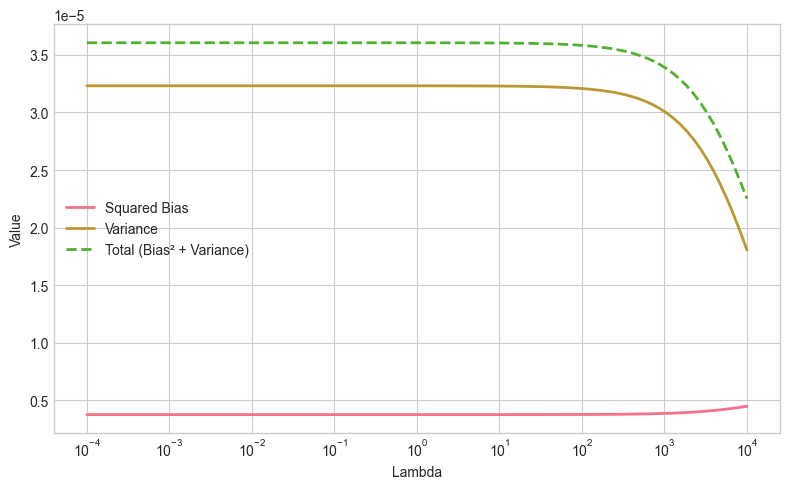

In [3]:
#| label: fig-ridgetrade
#| fig-cap: "Error decomposition for a ridge regression."

# Prepare data for ridge regression
x_penalized_train = training_sample[features_short].values
y_penalized_train = training_sample['R1M'].values
x_penalized_test = testing_sample[features_short].values
y_penalized_test = testing_sample['R1M'].values

# Range of lambda values
lambdas = np.logspace(-4, 4, 100)

# Store predictions for each lambda
predictions_all = np.zeros((len(y_penalized_test), len(lambdas)))

for i, lam in enumerate(lambdas):
    ridge = Ridge(alpha=lam, fit_intercept=True)
    ridge.fit(x_penalized_train, y_penalized_train)
    predictions_all[:, i] = ridge.predict(x_penalized_test)

# Calculate errors, bias, and variance for each lambda
errors = predictions_all - y_penalized_test.reshape(-1, 1)
ridge_bias = errors.mean(axis=0)          # Bias
ridge_var = predictions_all.var(axis=0)   # Variance of predictions

# Plot error decomposition
plt.figure(figsize=(8, 5))
plt.plot(lambdas, ridge_bias**2, label='Squared Bias', linewidth=2)
plt.plot(lambdas, ridge_var, label='Variance', linewidth=2)
plt.plot(lambdas, ridge_bias**2 + ridge_var, label='Total (Bias² + Variance)', linewidth=2, linestyle='--')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

In [](#fig-ridgetrade), the pattern is different from the one depicted in [](#fig-varbiastrade). In the graph, when the intensity lambda increases, the magnitude of parameters shrinks and the model becomes simpler. Hence, the most simple model seems like the best choice: adding complexity increases variance but does not improve the bias! One possible reason for that is that features don't actually carry much predictive value and hence a constant model is just as good as more sophisticated ones based on irrelevant variables.

### The variance-bias tradeoff: illustration

The variance-bias tradeoff is often presented in theoretical terms that are easy to grasp. It is nonetheless useful to demonstrate how it operates on true algorithmic choices. Below, we take the example of trees because their complexity is easy to evaluate. Basically, a tree with many terminal nodes is more complex than a tree with a handful of clusters.

We start with the parsimonious model, which we train below.

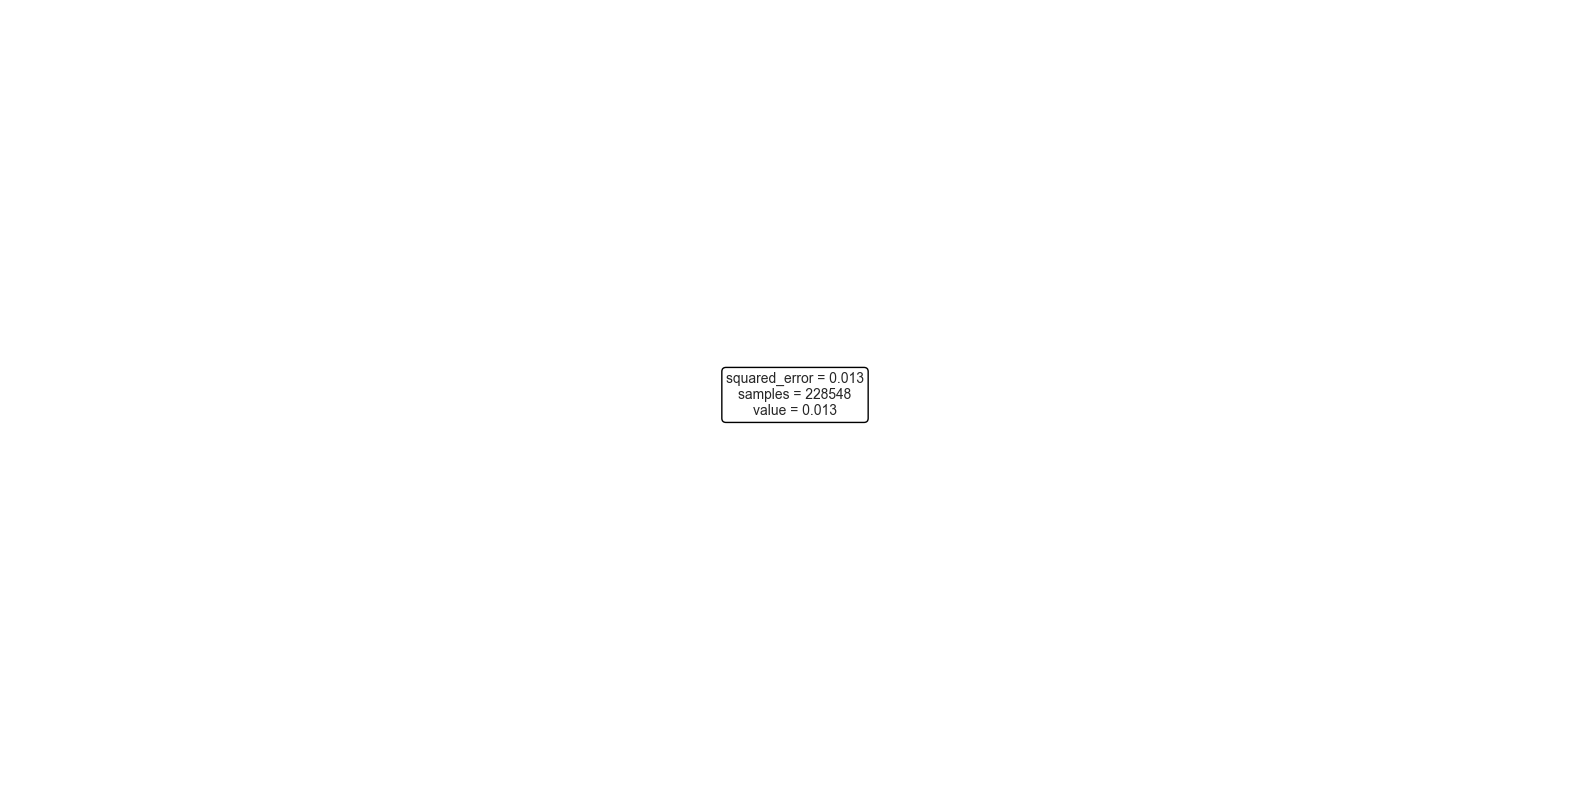

In [4]:
#| label: fig-treesimple
#| fig-cap: "Simple tree."

# Prepare training data
X_train = training_sample[features_short]
y_train = training_sample['R1M']
X_test = testing_sample[features_short]
y_test = testing_sample['R1M']

# Train a simple tree with max_depth=2
fit_tree_simple = DecisionTreeRegressor(
    ccp_alpha=0.0001,   # Complexity parameter: smaller = more leaves
    max_depth=2         # Maximum depth (i.e. tree levels)
)
fit_tree_simple.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(16, 8))
plot_tree(fit_tree_simple, feature_names=features_short, filled=True, rounded=True, fontsize=10)
plt.tight_layout()
plt.show()

The model depicted in [](#fig-treesimple) only has 4 clusters, which means that the predictions can only take four values. The smallest one encompasses a large portion of the sample and the largest one corresponds to only a small fraction of the training sample.  

We are then able to compute the bias and the variance of the predictions on the *testing* set.

In [5]:
# Bias and variance for simple tree
predictions_simple = fit_tree_simple.predict(X_test)
bias_simple = np.mean(predictions_simple - y_test)
var_simple = np.var(predictions_simple)

print(f"Bias (simple tree): {bias_simple:.5f}")
print(f"Variance (simple tree): {var_simple:.5f}")

Bias (simple tree): 0.00252
Variance (simple tree): 0.00000


On average, the error is slightly positive, with an overall overestimation. As expected, the variance is very small.

For the complex model, we take a boosted tree (XGBoost). The model aggregates multiple trees with a maximum depth of 4, it is thus undoubtedly more complex.

In [6]:
# Prepare XGBoost data
train_features_xgb = training_sample[features_short].values
train_label_xgb = training_sample['R1M'].values
train_matrix_xgb = xgb.DMatrix(data=train_features_xgb, label=train_label_xgb)

# XGBoost parameters
params = {
    'eta': 0.3,
    'objective': 'reg:squarederror',
    'max_depth': 4,
    'lambda': 1,
    'gamma': 0.1,
    'verbosity': 0
}

# Train XGBoost model
fit_xgb = xgb.train(
    params=params,
    dtrain=train_matrix_xgb,
    num_boost_round=40
)

# Test sample => XGB format
xgb_test = xgb.DMatrix(testing_sample[features_short].values)

# Bias and variance for complex model (XGBoost)
predictions_xgb = fit_xgb.predict(xgb_test)
bias_xgb = np.mean(predictions_xgb - y_test)
var_xgb = np.var(predictions_xgb)

print(f"Bias (XGBoost): {bias_xgb:.6f}")
print(f"Variance (XGBoost): {var_xgb:.6f}")

Bias (XGBoost): 0.003055
Variance (XGBoost): 0.000064


The bias is indeed smaller compared to that of the simple model, but in exchange, the variance increases substantially. The net effect (via the *squared bias*) is in favor of the simpler model.

### The risk of overfitting: principle

The notion of **overfitting** is one of the most important in machine learning. When a model overfits, the accuracy of its predictions will be disappointing, thus it is one major reason why *some* strategies fail out-of-sample. Therefore, it is important to understand not only what overfitting is, but also how to mitigate its effects.

One recent reference on this topic and its impact on portfolio strategies is @hsu2018asset, which builds on the work of @white2000reality. Both of these references do not deal with ML models, but the principle is the same. When given a dataset, a sufficiently intense level of analysis (by a human or a machine) will always be able to detect some patterns. Whether these patterns are spurious or not is the key question.

In [](#fig-overfit), we illustrate this idea with a simple visual example. We try to find a model that maps x into y. The (training) data points are the small black circles. The simplest model is the constant one (only one parameter), but with two parameters (level and slope), the fit is already quite good. This is shown with the blue line. With a sufficient number of parameters, it is possible to build a model that flows through all the points. One example would be a high-dimensional polynomial. One such model is represented with the red line. Now there seems to be a strange point in the dataset and the complex model fits closely to match this point. 

```{figure} images/overfitting.png
:name: fig-overfit
:align: center
Illustration of overfitting: a model closely matching training data is rarely a good idea.
```

A new point is added in light green. It is fair to say that it follows the general pattern of the other points. The simple model is not perfect and the error is non-negligible. Nevertheless, the error stemming from the complex model (shown with the dotted gray line) is approximately twice as large. This simplified example shows that models that are too close to the training data will catch idiosyncracies that will not occur in other datasets. A good model would overlook these idiosyncracies and stick to the enduring structure of the data.

### The risk of overfitting: some solutions

Obviously, the easiest way to avoid overfitting is to resist the temptation of complicated models (e.g., high-dimensional neural networks or tree ensembles). 

The complexity of models is often proxied via two measures: the number of parameters of the model and their magnitude (often synthesized through their norm). These proxies are not perfect because some *complex* models may only require a small number of parameters (or even small parameter values), but at least they are straightforward and easy to handle. There is no universal way of handling overfitting. Below, we detail a few tricks for some families of ML tools.

For **regressions**, there are two simple ways to deal with overfitting. The first is the number of parameters, that is, the number of predictors. Sometimes, it can be better to only select a subsample of features, especially if some of them are highly correlated (often, a threshold of 70% is considered as too high for absolute correlations between features). The second solution is penalization (via LASSO, ridge or elasticnet), which helps reduce the magnitude of estimates and thus of the variance of predictions.

For tree-based methods, there are a variety of ways to reduce the risk of overfitting. When dealing with **simple trees**, the only way to proceed is to limit the number of leaves. This can be done in many ways. First, by imposing a maximum depth. If it is equal to $d$, then the tree can have at most $2^d$ terminal nodes. It is often advised not to go beyond $d=6$. The complexity parameter in *rpart* (cp) is another way to shrink the size of trees: any new split must lead to a reduction in loss at least equal to cp. If not, the split is not deemed useful and is thus not performed. Thus when cp is large, the tree is not grown. The last two parameters available in *rpart* are the minimum number of instances required in each leaf and the minimum number of instances per cluster requested in order to continue the splitting process. The higher (i.e., the more coercive) these figures are, the harder it is to grow complex trees. 

In addition to these options, **random forests** allow to control for the number of trees in the forest. Theoretically (see @breiman2001random), this parameter is not supposed to impact the risk of overfitting because new trees only help reduce the total error via diversification. In practice, and for the sake of computation times, it is not recommended to go beyond 1,000 trees. Two other hyperparameters are the subsample size (on which each learner is trained) and the number of features retained for learning. They do not have a straightforward impact on bias and tradeoff, but rather on raw performace. For instance, if subsamples are too small, the trees will not learn enough. Same problem if the number of features is too low. On the other hand, choosing a large number of predictors (i.e., close to the total number) may lead to high correlations between each learner's prediction because the overlap in information contained in the training samples may be high.

**Boosted trees** have other options that can help alleviate the risk of overfitting. The most obvious one is the learning rate, which discounts the impact of each new tree by $\eta \in (0,1)$. When the learning rate is high, the algorithm learns too quickly and is prone to sticking close to the training data. When it's low, the model learns very progressively, which can be efficient if there are sufficiently many trees in the ensemble. Indeed, the learning rate and the number of trees must be chosen synchronously: if both are low, the ensemble will learn nothing and if both are large, it will overfit. The arsenal of boosted tree parameters does not stop there. The penalizations, both of score values and of the number of leaves, are naturally a tool to prevent the model from going too deep in the particularities of the training sample. Finally, constraints of monotonicity like those mentioned in {ref}`sec_boostext` are also an efficient way to impose some structure on the model and force it to detect particular patterns. 

Lastly **neural networks** also have many options aimed at protecting them against overfitting. Just like for boosted trees, some of them are the learning rate and the penalization of weights and biases (via their norm). Constraints, like nonnegative constraints, can also help when the model theoretically requires positive inputs. Finally, dropout is always a direct way to reduce the dimension (number of parameters) of a network.

## The search for good hyperparameters

### Methods

Let us assume that there are $p$ parameters to be defined before a model is run. The simplest way to proceed is to test different values of these parameters and choose the one that yields the best results. There are mainly two ways to perform these tests: independently and sequentially.

Independent tests are easy and come in two families: grid (deterministic) search and random exploration. The advantage of a deterministic approach is that it covers the space uniformly and makes sure that no corners are omitted. The drawback is the computation time. Indeed, for each parameter, it seems reasonable to test at least five values, which makes $5^p$ combinations. If $p$ is small (smaller than 3), this is manageable when the backtests are not too lengthy. When $p$ is large, the number of combinations may become prohibitive. This is when random exploration can be useful because in this case, the user specifies the number of tests upfront and the parameters are drawn randomly (usually uniformly over a given range for each parameter). The flaw in random search is that some areas in the parameter space may not be covered, which can be problematic if the best choice is located there. It is nonetheless shown in @bergstra2012random that random exploration is preferable to grid search.

Both grid and random searches are suboptimal because they are likely to spend time in zones of the parameter space that are irrelevant, thereby wasting computation time. Given a number of parameter points that have been tested, it is preferable to focus the search in areas where the best points are the most likely. This is possible via an interative process that adapts the search after each new point has been tested. In the large field of finance, a few papers dedicated to tuning are @lee2020hyperparameter and @nystrup2020hyperparameter.

One other popular approach in this direction is **Bayesian optimization** (BO). The central object is the objective function of the learning process. We call this function $O$ and it can be widely seen as a loss function possibly combined with penalization and constraints. For simplicity here, we will not mention the training/testing samples and they are considered to be fixed. The variable of interest is the vector $\textbf{p}=(p_1,\dots,p_l)$ which synthesizes the hyperparameters (learning rate, penalization intensities, number of models, etc.) that have an impact on $O$. The program we are interested in is 

$$
\textbf{p}_*=\underset{\textbf{p}}{\text{argmin}} \ O(\textbf{p}).
$$ (eq-HPO)

The main problem with this optimization is that the computation of $O(\textbf{p})$ is very costly. Therefore, it is critical to choose each trial for $\textbf{p}$ wisely. One key assumption of BO is that the distribution of $O$ is Gaussian and that $O$ can be proxied by a linear combination of the $p_l$. Said differently, the aim is to build a Bayesian linear regression between the input $\textbf{p}$ and the output (dependent variable) $O$. Once a model has been estimated, the information that is concentrated in the posterior density of $O$ is used to make an educated guess at where to look for new values of $\textbf{p}$.

This educated guess is made based on a so-called **acquisition function**. Suppose we have tested $m$ values for $\textbf{p}$, which we write $\textbf{p}^{(m)}$. The current best parameter is written $\textbf{p}_m^*=\underset{1\le k\le m}{\text{argmin}} \ O(\textbf{p}^{(k)})$. If we test a new point $\textbf{p}$, then it will lead to an improvement only if $O(\textbf{p})<O(\textbf{p}_m^*)$, that is if the new objective improves the minimum value that we already know. The average value of this improvement is

$$
\textbf{EI}_m(\textbf{p})=\mathbb{E}_m[[O(\textbf{p}_m^*)-O(\textbf{p})]_+],
$$ (eq-acquisition)

where the positive part $[\cdot]_+$ emphasizes that when $O(\textbf{p})\ge O(\textbf{p}_m^*)$, the gain is zero. The expectation is indexed by $m$ because it is computed with respect to the posterior distribution of $O(\textbf{p})$ based on the $m$ samples $\textbf{p}^{(m)}$. The best choice for the next sample $\textbf{p}^{m+1}$ is then

$$
\textbf{p}^{m+1}=\underset{\textbf{p}}{\text{argmax}} \ \textbf{EI}_m(\textbf{p}),
$$ (eq-EI)

which corresponds to the maximum location of the expected improvement. Instead of the EI, the optimization can be performed on other measures, like the probability of improvement, which is $\mathbb{P}_m[O(\textbf{p})<O(\textbf{p}_m^*)]$.

In compact form, the iterative process can be outlined as follows:  

- **step 1**: compute $O(\textbf{p}^{(m)})$ for $m=1,\dots,M_0$ values of parameters.    
- **step 2a**: compute sequentially the posterior density of $O$ on all available points.   
- **step 2b**: compute the optimal new point to test $\textbf{p}^{(m+1)}$ given in Equation {eq}`eq-EI`.   
- **step 2c**: compute the new objective value $O(\textbf{p}^{(m+1)})$.  
- **step 3**: repeat steps 2a to 2c as much as deemed reasonable and return the $\textbf{p}^{(m)}$ that yields the smallest objective value.   

The interested reader can have a look at @snoek2012practical and @frazier2018tutorial for more details on the numerical facets of this method.

Finally, for the sake of completeness, we mention a last way to tune hyperparameters. Since the optimization scheme is $\underset{\textbf{p}}{\text{argmin}} \ O(\textbf{p})$, a natural way to proceed would be to use the sensitivity of $O$ with respect to $\textbf{p}$. Indeed, if the gradient $\frac{\partial O}{\partial p_l}$ is known, then a gradient descent will always improve the objective value. The problem is that it is hard to compute a reliable gradient (finite differences can become costly). Nonetheless, some methods (e.g., @maclaurin2015gradient) have been applied successfully to optimize over large dimensional parameter spaces.

We conclude by mentioning the survey @bouthillier2020survey, which spans 2 major AI conferences that took place in 2019. It shows that most papers resort to hyperparameter tuning. The two most often cited methods are *manual tuning* (hand-picking) and *grid search*.

### Example: grid search

In order to illustrate the process of grid search, we will try to find the best parameters for a boosted tree. We seek to quantify the impact of three parameters:   

- **eta**, the learning rate,   
- **nrounds**, the number of trees that are grown,  
- **lambda**, the weight regularizer which penalizes the objective function through the total sum of squared weights/scores.

Below, we create a grid with the values we want to test for these parameters.

In [7]:
# Values for hyperparameters
eta_vals = [0.1, 0.3, 0.5, 0.7, 0.9]       # Values for eta
nrounds_vals = [10, 50, 100]               # Values for nrounds
lambda_vals = [0.01, 0.1, 1, 10, 100]      # Values for lambda

# Create all combinations
pars = list(product(eta_vals, nrounds_vals, lambda_vals))
print(f"Number of parameter combinations: {len(pars)}")
print("First few combinations:")
for p in pars[:6]:
    print(f"  eta={p[0]}, nrounds={p[1]}, lambda={p[2]}")

Number of parameter combinations: 75
First few combinations:
  eta=0.1, nrounds=10, lambda=0.01
  eta=0.1, nrounds=10, lambda=0.1
  eta=0.1, nrounds=10, lambda=1
  eta=0.1, nrounds=10, lambda=10
  eta=0.1, nrounds=10, lambda=100
  eta=0.1, nrounds=50, lambda=0.01


Given the computational cost of grid search, we perform the exploration on the dataset with the small number of features. We define a function that takes data and parameter inputs and returns an error metric for the algorithm. We choose the mean squared error to evaluate the impact of hyperparameter values.

In [8]:
def grid_par(train_matrix, test_features, test_label, eta, nrounds, lambda_val):
    """Train XGBoost with given parameters and return MSE."""
    params = {
        'eta': eta,
        'objective': 'reg:squarederror',
        'max_depth': 5,
        'lambda': lambda_val,
        'gamma': 0.1,
        'verbosity': 0
    }
    
    fit = xgb.train(
        params=params,
        dtrain=train_matrix,
        num_boost_round=nrounds
    )
    
    pred = fit.predict(test_features)
    return np.mean((pred - test_label) ** 2)  # Mean squared error

In [9]:
# Prepare XGBoost matrices
train_matrix_xgb = xgb.DMatrix(
    data=training_sample[features_short].values,
    label=training_sample['R1M'].values
)
xgb_test = xgb.DMatrix(testing_sample[features_short].values)
test_label = testing_sample['R1M'].values

# Run grid search
results = []
for eta, nrounds, lambda_val in pars:
    error = grid_par(train_matrix_xgb, xgb_test, test_label, eta, nrounds, lambda_val)
    results.append({
        'eta': eta,
        'nrounds': nrounds,
        'lambda': lambda_val,
        'error': error
    })

# Convert to DataFrame
grd = pd.DataFrame(results)
print(grd.head(10))

   eta  nrounds  lambda     error
0  0.1       10    0.01  0.015553
1  0.1       10    0.10  0.015550
2  0.1       10    1.00  0.015550
3  0.1       10   10.00  0.015546
4  0.1       10  100.00  0.015546
5  0.1       50    0.01  0.015597
6  0.1       50    0.10  0.015617
7  0.1       50    1.00  0.015559
8  0.1       50   10.00  0.015568
9  0.1       50  100.00  0.015546


Once the squared mean errors have been gathered, it is possible to plot them. We chose to work with 3 parameters on purpose because their influence can be simultaneuously plotted on one graph.

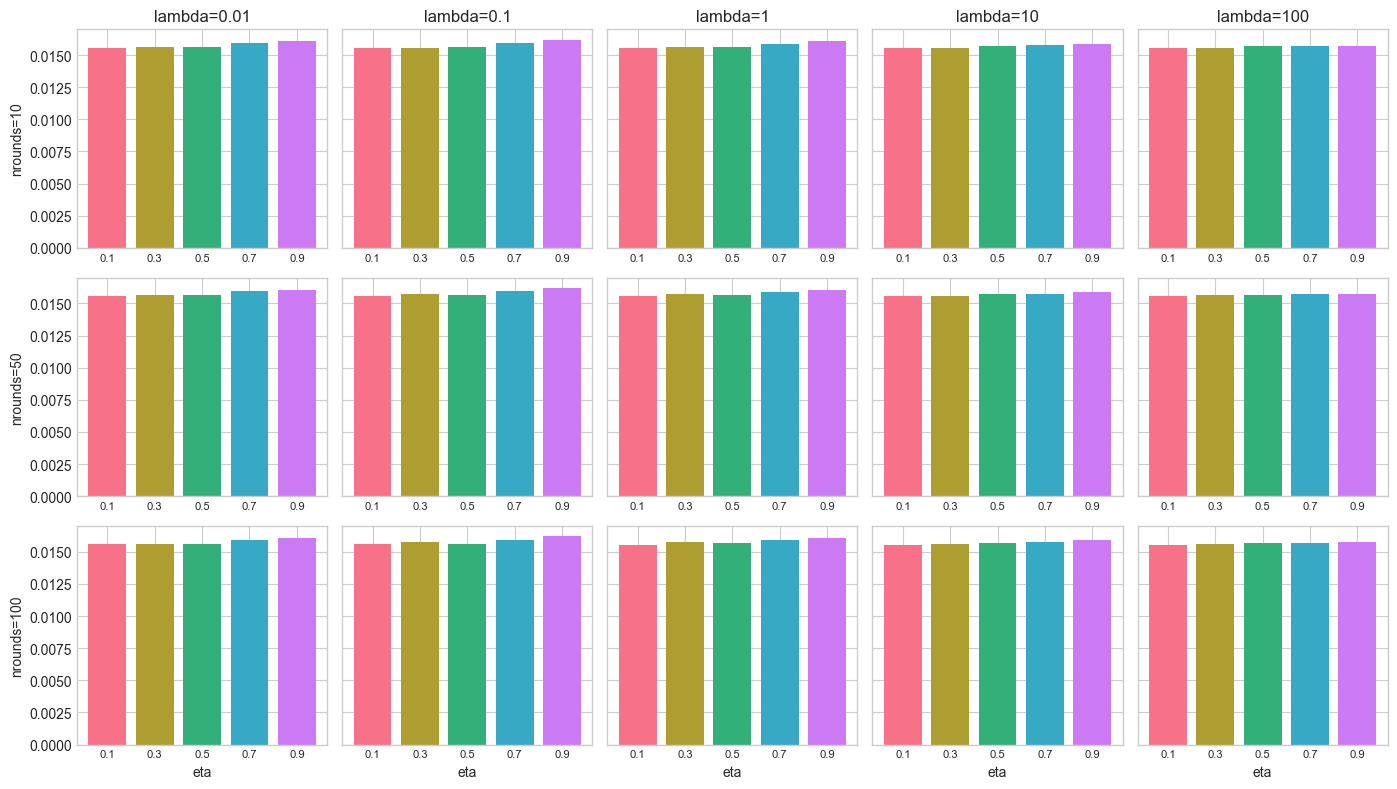

In [10]:
#| label: fig-gridvisu
#| fig-cap: "Plot of error metrics (MSEs) for many parameter values. Each row of graph corresponds to nrounds and each column to lambda."

# Create faceted bar plot
grd['eta_str'] = grd['eta'].astype(str)

fig, axes = plt.subplots(len(nrounds_vals), len(lambda_vals), figsize=(14, 8), sharey=True)

for i, nr in enumerate(nrounds_vals):
    for j, lam in enumerate(lambda_vals):
        subset = grd[(grd['nrounds'] == nr) & (grd['lambda'] == lam)]
        ax = axes[i, j]
        bars = ax.bar(subset['eta_str'], subset['error'], color=sns.color_palette("husl", 5) )
        
        if i == 0:
            ax.set_title(f'lambda={lam}')
        if j == 0:
            ax.set_ylabel(f'nrounds={nr}')
        if i == len(nrounds_vals) - 1:
            ax.set_xlabel('eta')
        ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

In [](#fig-gridvisu), the main information is that a small learning rate ($\eta=0.1$) is detrimental to the quality of the forecasts when the number of trees is small (nrounds=10), which means that the algorithm does not learn enough.

Grid search can be performed in two stages: the first stage helps locate the zones that are of interest (with the lowest loss/objective values) and then zoom in on these zones with refined values for the parameter on the grid. With the results above, this would mean considering many learners (more than 50, possibly more than 100), and avoiding large learning rates such as $\eta=0.9$ or $\eta=0.8$.

### Example: Bayesian optimization

There are several packages in Python that relate to Bayesian optimization. We work with *scikit-optimize*, which provides a general-purpose implementation.

In [11]:
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.plots import plot_convergence

# Define the objective function (to minimize)
def bayes_objective(params):
    """Objective function for Bayesian optimization."""
    eta, lambda_val, nrounds = params
    
    xgb_params = {
        'eta': eta,
        'objective': 'reg:squarederror',
        'max_depth': 5,
        'lambda': lambda_val,
        'gamma': 0.1,
        'verbosity': 0
    }
    
    fit = xgb.train(
        params=xgb_params,
        dtrain=train_matrix_xgb,
        num_boost_round=int(nrounds)
    )
    
    pred = fit.predict(xgb_test)
    mse = np.mean((pred - test_label) ** 2)
    return mse  # Return MSE (to minimize)

# Define search space
search_space = [
    Real(0.2, 0.8, name='eta'),
    Real(0.1, 1.0, name='lambda'),
    Integer(10, 100, name='nrounds')
]

# Run Bayesian optimization
np.random.seed(42)
bayes_opt = gp_minimize(
    bayes_objective,
    search_space,
    n_calls=34,           # Total number of evaluations (10 initial + 24 iterations)
    n_initial_points=10,  # Number of initial random points
    acq_func='EI',        # Expected Improvement
    random_state=42,
    verbose=False
)

print("Best parameters found:")
print(f"  eta: {bayes_opt.x[0]:.4f}")
print(f"  lambda: {bayes_opt.x[1]:.4f}")
print(f"  nrounds: {bayes_opt.x[2]}")
print(f"  Best MSE: {bayes_opt.fun:.6f}")

Best parameters found:
  eta: 0.3118
  lambda: 0.3520
  nrounds: 26
  Best MSE: 0.015575


To confirm these results, we plot the relationship between the loss and hyperparameters. Each point corresponds to a value tested in the optimization.

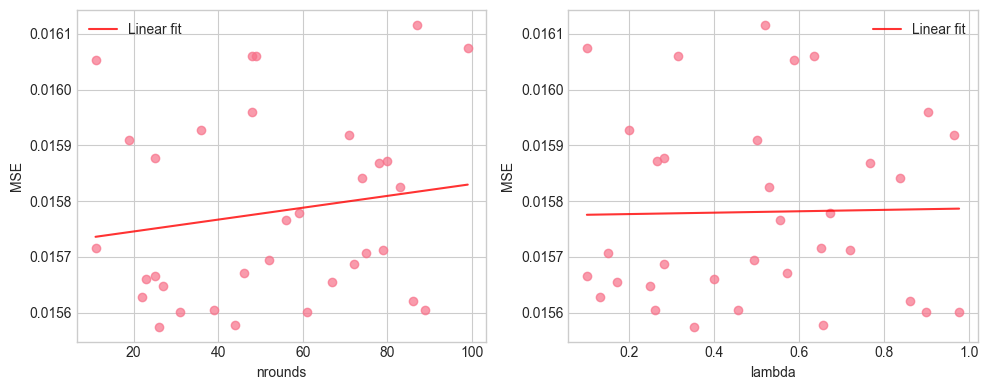

In [12]:
#| label: fig-bayesoptfig
#| fig-cap: "Relationship between the loss (MSE) and hyperparameter values."

# Extract history from optimization
history_df = pd.DataFrame({
    'eta': [x[0] for x in bayes_opt.x_iters],
    'lambda': [x[1] for x in bayes_opt.x_iters],
    'nrounds': [x[2] for x in bayes_opt.x_iters],
    'mse': bayes_opt.func_vals
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot nrounds vs MSE
axes[0].scatter(history_df['nrounds'], history_df['mse'], alpha=0.7)
z = np.polyfit(history_df['nrounds'], history_df['mse'], 1)
p = np.poly1d(z)
x_line = np.linspace(history_df['nrounds'].min(), history_df['nrounds'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r-', alpha=0.8, label='Linear fit')
axes[0].set_xlabel('nrounds')
axes[0].set_ylabel('MSE')
axes[0].legend()

# Plot lambda vs MSE
axes[1].scatter(history_df['lambda'], history_df['mse'], alpha=0.7)
z = np.polyfit(history_df['lambda'], history_df['mse'], 1)
p = np.poly1d(z)
x_line = np.linspace(history_df['lambda'].min(), history_df['lambda'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r-', alpha=0.8, label='Linear fit')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

## Short discussion on validation in backtests

The topic of validation in backtests is more complex than it seems. There are in fact two scales at which it can operate, depending on whether the forecasting model is dynamic (updated at each rebalancing) or fixed. 

Let us start with the first option. In this case, the aim is to build a unique model and to test it on different time periods. There is an ongoing debate on the methods that are suitable to validate a model in that case. Usually, it makes sense to test the model on successive dates, moving forward posterior to the training. This is what makes more sense, as it replicates what would happen in a live situation.

In machine learning, a popular approach is to split the data into $K$ partitions and to test $K$ different models: each one is tested on one of the partitions but trained on the $K-1$ others. This so-called **cross-validation** (CV) is proscribed by most experts (and common sense) for a simple reason: most of the time, the training set encompasses data from future dates and tests on past values. Nonetheless, some advocate one particular form of CV that aims at making sure that there is no informational overlap between the training and testing set (Sections 7.4 and 12.4 in @de2018advances). The premise is that if the structure of the cross-section of returns is constant through time, then training on future points and testing on past data is not problematic as long as there is no overlap. The paper @schnaubelt2019comparison provides a comprehensive and exhaustive tour in many validation schemes.

One example cited in @de2018advances is the reaction to a model to an unseen crisis. Following the market crash of 2008, at least 11 years have followed without any major financial shake. One option to test the reaction of a recent model to a crash would be to train it on recent years (say 2015-2019) and test it on various points (e.g., months) in 2008 to see how it performs.

The advantage of a fixed model is that validation is easy: for one set of hyperparameters, test the model on a set of dates, and evaluate the performance of the model. Repeat the process for other parameters and choose the best alternative (or use Bayesian optimization).

The second major option is when the model is updated (retrained) at each rebalancing. The underlying idea here is that the structure of returns evolves through time and a dynamic model will capture the most recent trends. The drawback is that validation must (should?) be rerun at each rebalancing date. 

Let us recall the dimensions of backtests:   
- number of **strategies**: possibly dozens or hundreds, or even more;   
- number of trading **dates**: hundreds for monthly rebalancing;   
- number of **assets**: hundreds or thousands;    
- number of **features**: dozens or hundreds.  

Even with a lot of computational power (GPUs, etc.), training many models over many dates is time-consuming, especially when it comes to hyperparameter tuning when the parameter space is large. Thus, validating models at each trading date of the out-of-sample period is not realistic. 

One solution is to keep an early portion of the training data and to perform a smaller scale validation on this subsample. Hyperparameters are tested on a limited number of dates and most of the time, they exhibit stability: satisfactory parameters for one date are usually acceptable for the next one and the following one as well. Thus, the full backtest can be carried out with these values when updating the models at each period. The backtest nonetheless remains compute-intensive because the model has to be retrained with the most recent data for each rebalancing date.